# v4 — Pipeline hiện hành

> Chấp nhận tụt 4 điểm để đổi lấy một con số dùng được.

| | |
|---|---|
| Kênh tín hiệu | PPG (đúng loại cảm biến của vòng đeo) |
| Cửa sổ | 30 giây, bước 10 giây → chồng 67% ✅ an toàn |
| Đặc trưng | 13 cột = 16 trừ nhóm LF |
| Làm sạch | IQR ×3.0, ngưỡng tính **trên train**, chỉ xóa hàng train ✅ |
| Chuẩn hóa | StandardScaler trong Pipeline, fit lại **theo từng fold** ✅ |
| Chia dữ liệu | **LOSO theo bệnh nhân** ✅ |
| **Kết quả thật** | **94.29% mức bệnh nhân, recall 100%** |

## 1. Ba sửa chữa cốt lõi

**a) Chia theo bệnh nhân (LOSO).** Mỗi vòng giữ trọn một người ra ngoài, học
trên 34 người còn lại. Làm 35 vòng cho đủ mọi người. Không một cửa sổ nào của
người test xuất hiện trong train.

**b) Tiền xử lý chỉ nhìn train.** Scaler nằm trong `Pipeline` nên fit lại theo
từng fold. Lọc outlier tính ngưỡng trên train và **chỉ xóa hàng train**; tập
test giữ nguyên 100%. Ngoài đời không ai được phép vứt dữ liệu của bệnh nhân
mới chỉ vì nó khó.

**c) Tinh chỉnh lồng bên trong.** `GridSearchCV` chạy với `GroupKFold(3)` bên
trong mỗi fold LOSO, nên test của fold không tham gia chọn hyperparameter.

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CWD = os.path.abspath('')
SRC = os.path.dirname(CWD) if os.path.basename(CWD) == 'report' else CWD
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from vlab import store, viz, honest
from vlab.extract import extract_table

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 40)
%matplotlib inline
print('San sang. src =', SRC)


San sang. src = D:\Projects\HealthSense\HealthSense-MachineLearning-Lab\src


In [2]:
import v4
r = store.load('v4')
if r is None:
    r = v4.run()

print('Cấu hình v4:')
for k, val in r['config'].items():
    if k != 'features':
        print(f'  {k:12}: {val}')
print()
print('Đã sửa:')
for f in r['fixes']:
    print(f'  ✅ {f}')

Cấu hình v4:
  channel     : PPG
  window_s    : 30.0
  step_s      : 10.0
  overlap_pct : 66.7
  n_features  : 13
  cleaning    : IQR x3.0, ngưỡng chỉ tính trên train của fold
  scaling     : StandardScaler trong Pipeline, fit lại theo từng fold
  split       : LOSO theo record_id (bệnh nhân)
  model       : Random Forest (so sánh) / XGBoost tinh chỉnh lồng (sản phẩm)

Đã sửa:
  ✅ LOSO theo bệnh nhân: người ở test chưa từng xuất hiện trong train.
  ✅ Scaler fit lại theo từng fold, chỉ nhìn dữ liệu train.
  ✅ Lọc IQR tính trên train và chỉ xóa hàng train; test giữ nguyên 100%.
  ✅ Tinh chỉnh hyperparameter lồng trong fold bằng GroupKFold.
  ✅ Bỏ nhóm LF vì cửa sổ 30 giây quá ngắn để ước lượng dải tần này.


## 2. Chứng minh quan trọng nhất

Câu hỏi tự nhiên: "Biết đâu v4 điểm thấp chỉ vì dữ liệu của nó khó hơn, hoặc
mô hình của nó kém hơn?"

Cách kiểm tra: đem **chính dữ liệu v4** ra chấm theo cách cũ (chia ngẫu nhiên).

In [3]:
old_way = r['if_graded_the_old_way']
loso_w = r['regraded_loso_window']
loso_s = r['regraded_loso_subject']

so_sanh = pd.DataFrame([
    {'Cách chấm': 'Nếu chấm kiểu cũ (chia ngẫu nhiên)',
     'Accuracy': old_way['accuracy'], 'Recall': old_way['recall'],
     'Specificity': old_way['specificity'], 'ROC-AUC': old_way['roc_auc']},
    {'Cách chấm': 'Cách v4 thật sự dùng (LOSO)',
     'Accuracy': loso_w['accuracy'], 'Recall': loso_w['recall'],
     'Specificity': loso_w['specificity'], 'ROC-AUC': loso_w['roc_auc']},
])
display(so_sanh)

print(f"Dữ liệu v4 chấm kiểu cũ cũng cho {old_way['accuracy']*100:.2f}% —")
print('ngang ngửa v3. Nghĩa là dữ liệu không hề khó hơn, mô hình không hề kém hơn.')
print('TOÀN BỘ chênh lệch nằm ở CÁCH CHẤM ĐIỂM.')

,Cách chấm,Accuracy,Recall,Specificity,ROC-AUC
0,Nếu chấm kiểu cũ (chia ngẫu nhiên),0.9806,0.9821,0.9788,0.9967
1,Cách v4 thật sự dùng (LOSO),0.9167,0.9648,0.8596,0.9319


Dữ liệu v4 chấm kiểu cũ cũng cho 98.06% —
ngang ngửa v3. Nghĩa là dữ liệu không hề khó hơn, mô hình không hề kém hơn.
TOÀN BỘ chênh lệch nằm ở CÁCH CHẤM ĐIỂM.


Đây là kết luận trung tâm của cả bảo tàng phiên bản:

> **Các phiên bản trước không có mô hình tệ. Chúng có một cái thước đo hỏng.**

v4 không phải là bước lùi về năng lực. Nó là lần đầu tiên dự án nhìn thấy
năng lực thật của mình.

## 3. Vì sao v4 vẫn dùng cửa sổ chồng lấn mà không sao?

Điểm này hay gây nhầm, vì v3 đã bị chồng lấn hại nặng.

Chồng lấn **tự nó không phải leakage**. Nó chỉ nguy hiểm khi **đi kèm chia
ngẫu nhiên** — lúc đó bản sao gần đúng của cửa sổ test nằm sẵn trong train.

Với LOSO, toàn bộ cửa sổ của một người nằm trọn về một phía của ranh giới.
Chúng chồng lên nhau bao nhiêu cũng không thể vượt qua ranh giới đó. Khi ấy
chồng lấn chỉ còn tác dụng tốt: có thêm mẫu để học từ cùng một lượng tín hiệu.

In [4]:
df = extract_table('PPG', 30.0, 10.0, verbose=False)
mot = df[df.record_id == df.record_id.iloc[0]]
print(f"Bệnh nhân {mot.record_id.iloc[0]}: {len(mot)} cửa sổ, chồng lấn 67%")
print('Trong LOSO, TOÀN BỘ 118 cửa sổ này nằm cùng một phía:')
print('  - hoặc tất cả trong train (khi đang test người khác)')
print('  - hoặc tất cả trong test  (khi đến lượt người này bị giữ ra)')
print('\nKhông có cách nào một cửa sổ của người này lọt sang phía bên kia.')

Bệnh nhân mimic_perform_af_001: 118 cửa sổ, chồng lấn 67%
Trong LOSO, TOÀN BỘ 118 cửa sổ này nằm cùng một phía:
  - hoặc tất cả trong train (khi đang test người khác)
  - hoặc tất cả trong test  (khi đến lượt người này bị giữ ra)

Không có cách nào một cửa sổ của người này lọt sang phía bên kia.


## 4. Vì sao bỏ nhóm đặc trưng LF?

`LF`, `LF_norm`, `LF_HF_Ratio` bị loại khỏi bộ huấn luyện, còn 13 cột.

Lý do thuần y học: chuẩn **Task Force 1996** yêu cầu bản ghi **tối thiểu 2
phút** mới ước lượng được dải tần thấp (LF). Cửa sổ ở đây chỉ 30 giây.

Con số tính ra vẫn là một số thực trông có vẻ hợp lý — máy tính không báo lỗi.
Nhưng về mặt sinh lý nó vô nghĩa. Giữ lại chỉ là tự lừa mình.

Pipeline vẫn **tính** đủ 16 cột để tương thích, chỉ không **huấn luyện** trên
3 cột đó.

In [5]:
print('13 đặc trưng v4 dùng để huấn luyện:')
for i, f in enumerate(r['config']['features'], 1):
    print(f'  {i:>2}. {f}')
print('\n3 cột bị loại (nhóm LF): LF, LF_norm, LF_HF_Ratio')
print('   -> cần bản ghi >= 2 phút mới đáng tin, cửa sổ chỉ có 30 giây')

13 đặc trưng v4 dùng để huấn luyện:
   1. HR_mean
   2. Mean_NN
   3. SDNN
   4. RMSSD
   5. NN50
   6. pNN50
   7. CV
   8. HF
   9. Total_Power
  10. HF_norm
  11. SD1
  12. SD2
  13. SampEn

3 cột bị loại (nhóm LF): LF, LF_norm, LF_HF_Ratio
   -> cần bản ghi >= 2 phút mới đáng tin, cửa sổ chỉ có 30 giây


## 5. Kết quả mức bệnh nhân

Bác sĩ chẩn đoán **con người**, không chẩn đoán từng đoạn 30 giây. Gộp toàn
bộ cửa sổ của mỗi người thành một điểm số duy nhất:

LOSO mức bệnh nhân — 35 người:
  Accuracy    : 94.29%
  Recall      : 100.00%  <- bắt được bao nhiêu ca AFib
  Specificity : 87.50%


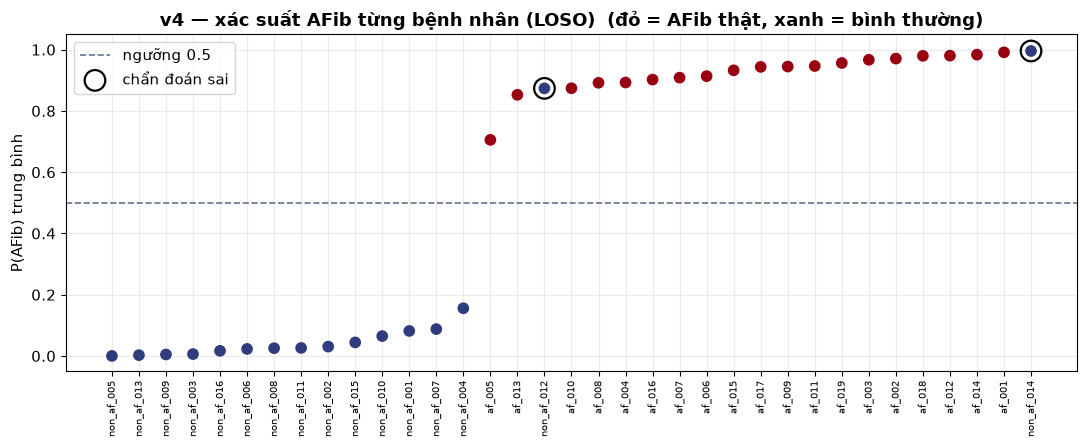

In [6]:
print(f"LOSO mức bệnh nhân — {loso_s['n_subjects']} người:")
print(f"  Accuracy    : {loso_s['accuracy']*100:.2f}%")
print(f"  Recall      : {loso_s['recall']*100:.2f}%  <- bắt được bao nhiêu ca AFib")
print(f"  Specificity : {loso_s['specificity']*100:.2f}%")

fig = viz.subject_probabilities(
    {'subjects': r['subject_detail']['subjects'],
     'subject_proba': r['subject_detail']['proba'],
     'subject_true': r['subject_detail']['true']},
    title='v4 — xác suất AFib từng bệnh nhân (LOSO)')
plt.show()

**Recall 100%** nghĩa là không bỏ sót ca AFib nào trong 19 bệnh nhân AFib.

Với bài toán sàng lọc thì đây là chỉ số quan trọng nhất: bỏ sót một ca AFib
có thể dẫn tới đột quỵ, còn báo động giả chỉ tốn một lần khám lại.

## 6. Kiểm định ba tầng

Con số 94.29% mới là **tầng 1**. Mô hình đang chạy trong sản phẩm còn qua hai
tầng nữa:

| Tầng | Cách kiểm | Ý nghĩa |
|---|---|---|
| 1. LOSO trên MIMIC | giữ ra từng bệnh nhân | Gặp người lạ, cùng bộ dữ liệu |
| 2. **Chéo bộ dữ liệu** | học MIMIC → thi AFDB, và ngược lại | Gặp bộ dữ liệu lạ, thiết bị lạ |
| 3. Gộp 60 bệnh nhân | LOSO trên MIMIC + AFDB | Mô hình cuối cùng đưa vào sản phẩm |

Tầng 2 là tầng khắt khe nhất. Qua được nó mới tin được mô hình học **dấu hiệu
của AFib** chứ không phải **đặc điểm của bộ dữ liệu**.

In [7]:
prod = r.get('production')
if prod:
    ev = prod['evaluation']
    print(f"Mô hình sản phẩm: {prod['model']}")
    print(f"  Huấn luyện trên : {prod['trained_on']}")
    print(f"  Số cửa sổ       : {prod['training_windows']:,}")
    print()
    print('Tầng 1 — LOSO MIMIC (mức bệnh nhân):')
    m = ev['mimic_loso_subject_v4']
    print(f"  accuracy {m['accuracy']:.4f} | recall {m['recall']:.4f} | AUC {m['roc_auc']:.4f}")
    print()
    print('Tầng 2 — Chéo bộ dữ liệu:')
    c = ev['cross_dataset']
    print(f"  học MIMIC -> thi AFDB : AUC {c['mimic_to_afdb_auc']:.4f}")
    print(f"  học AFDB  -> thi MIMIC: AUC {c['afdb_to_mimic_auc']:.4f}")
    print()
    print('Tầng 3 — Gộp 60 bệnh nhân, LOSO:')
    p = ev['pooled_loso_window']
    print(f"  accuracy {p['accuracy']:.4f} | recall {p['recall']:.4f} | AUC {p['roc_auc']:.4f}")
    print()
    print('Giới hạn đã ghi rõ trong model card:')
    print(' ', prod['limitations'])
else:
    print('Chưa có models/final/model_card.json — chạy scripts/run_final_model.py')

Mô hình sản phẩm: XGBoost
  Huấn luyện trên : 60 patients: MIMIC PERform AF (35, PPG 125Hz) + MIT-BIH AFDB (25, ECG 250Hz)
  Số cửa sổ       : 31,305

Tầng 1 — LOSO MIMIC (mức bệnh nhân):
  accuracy 0.9429 | recall 1.0000 | AUC 0.9309

Tầng 2 — Chéo bộ dữ liệu:
  học MIMIC -> thi AFDB : AUC 0.9870
  học AFDB  -> thi MIMIC: AUC 0.9757

Tầng 3 — Gộp 60 bệnh nhân, LOSO:
  accuracy 0.9589 | recall 0.9716 | AUC 0.9883

Giới hạn đã ghi rõ trong model card:
  Chưa kiểm định trên PPG cổ tay (MAX30102) và dữ liệu ngoài bệnh viện. Không phải thiết bị chẩn đoán y tế.


## 7. Bảng tổng kết bốn phiên bản

,Phiên bản,Chấm kiểu cũ,Chấm bằng LOSO,Điểm ảo,Số lỗi rò rỉ
0,v1,0.9821,0.9207,0.0614,1
1,v2,0.9889,0.9257,0.0632,3
2,v3,0.9919,0.9199,0.0720,5
3,v4,0.9806,0.9167,0.0639,0


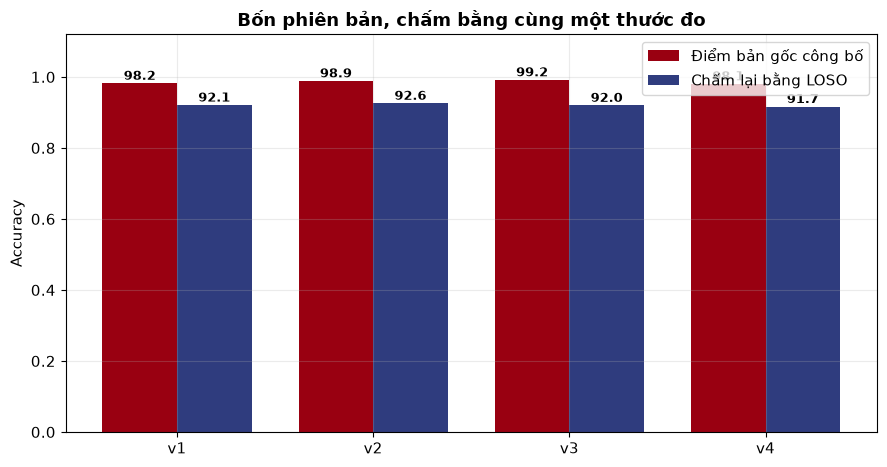

In [8]:
rows = []
for v in ['v1', 'v2', 'v3', 'v4']:
    rr = store.load(v)
    if rr is None:
        continue
    lk = rr.get('reproduced_leaky') or rr.get('if_graded_the_old_way')
    rows.append({
        'Phiên bản': v,
        'Chấm kiểu cũ': lk['accuracy'],
        'Chấm bằng LOSO': rr['regraded_loso_window']['accuracy'],
        'Điểm ảo': rr['inflation'],
        'Số lỗi rò rỉ': len(rr.get('leakage') or []),
    })
tong = pd.DataFrame(rows)
display(tong)

fig = viz.version_comparison([
    {'version': x['Phiên bản'], 'claimed': x['Chấm kiểu cũ'],
     'honest': x['Chấm bằng LOSO']} for x in rows])
plt.show()

## 8. Bài học rút ra

1. **Điểm thấp hơn không có nghĩa là mô hình tệ hơn.** Nó có thể nghĩa là
   cuối cùng bạn đang đo đúng.

2. **Ranh giới train/test phải trùng với ranh giới của thế giới thật.** Sản
   phẩm gặp *người mới*, nên ranh giới phải là *người*. Nếu sản phẩm gặp
   *bệnh viện mới* thì ranh giới phải là bệnh viện.

3. **Đưa mọi bước học vào `Pipeline`.** Đây là cách rẻ nhất để không bao giờ
   quên fit scaler trên train.

4. **Kiểm định chéo bộ dữ liệu là bài kiểm tra thật sự.** Nó trả lời câu hỏi
   duy nhất quan trọng: mô hình học bệnh, hay học bộ dữ liệu?

5. **Viết ra giới hạn của mình.** Model card ghi rõ: chưa kiểm định trên PPG
   cổ tay và dữ liệu ngoài bệnh viện; không phải thiết bị chẩn đoán y tế.
   Biết mình chưa chứng minh được gì cũng quan trọng ngang việc biết mình đã
   chứng minh được gì.

---

📖 Quay lại [`00_tong_quan.ipynb`](00_tong_quan.ipynb) để xem toàn cảnh.